# 03 — E-Explore (Full)

**Kelompok 14 | II4013 Data Analitik ITB**  
Cakupan: Eksplorasi data untuk Laporan Bab 4.

> Notebook ini membaca data bersih dari `data/processed/` (output `02_scrub.ipynb`).  
> Minimum 3 visualisasi dengan interpretasi tajam. Metode: statistik deskriptif,  
> distribusi, tren waktu, perbandingan kategori, hubungan antarvariabel.

In [1]:
# [AI-assisted] Setup Library, Path, dan Style Visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 65)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

PROCESSED_PATH = '../data/processed/'
FIGURES_DIR    = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
})
PAL_CAT = 'Set2'
PAL_SEQ = 'Blues_r'
print('Setup selesai.')

Setup selesai.


## Load Data Bersih

In [2]:
# Load Data Processed dari 02_scrub.ipynb
df1          = pd.read_csv(PROCESSED_PATH + 'ds1Clean.csv')
df_issues    = pd.read_csv(PROCESSED_PATH + 'ds2IssuesClean.csv')
df_utterances= pd.read_csv(PROCESSED_PATH + 'ds2UtterancesClean.csv')
df_scored    = pd.read_csv(PROCESSED_PATH + 'ds2ScoredClean.csv')
df_snapshot  = pd.read_csv(PROCESSED_PATH + 'ds2SnapshotClean.csv')

# Parse timestamp columns yang tersimpan sebagai string
TS_COLS_ISSUES = ['started_dt', 'ended_dt', 'issue_created_dt',
                  'issue_resolution_date_dt', 'last_change_date_dt']
for col in TS_COLS_ISSUES:
    if col in df_issues.columns:
        df_issues[col] = pd.to_datetime(df_issues[col], utc=True, errors='coerce')

datasets = {
    'ds1Clean'         : df1,
    'ds2IssuesClean'   : df_issues,
    'ds2UtterancesClean': df_utterances,
    'ds2ScoredClean'   : df_scored,
    'ds2SnapshotClean' : df_snapshot,
}
print('=== Data Loaded ===')
for name, df in datasets.items():
    print('  {:25s}: {:>7,} baris x {:>3} kolom'.format(name, *df.shape))

=== Data Loaded ===
  ds1Clean                 : 100,000 baris x  22 kolom
  ds2IssuesClean           :  66,691 baris x  57 kolom
  ds2UtterancesClean       :  14,455 baris x  12 kolom
  ds2ScoredClean           :     747 baris x  21 kolom
  ds2SnapshotClean         :  90,963 baris x  45 kolom


## Statistik Deskriptif

Tabel mean/median/std/min/max variabel numerik utama + value counts kategorikal.

In [3]:
# 8A — Statistik Deskriptif DS1
NUM_DS1 = [c for c in ['daysOpen','resolutionDurationDays','severityLevel',
                        'priorityLevel','seniorityLevel','satisfactionLevel',
                        'isLongTicket','isHighPriority','priorityVerified'] if c in df1.columns]
print('=== DS1 — Statistik Deskriptif Numerik ===')
display(df1[NUM_DS1].describe().round(2))
print()
print('=== DS1 — Value Counts Kategorikal ===')
for col in ['FiledAgainst', 'TicketType', 'severityLabel', 'priorityLabel', 'seniorityLabel']:
    if col not in df1.columns: continue
    vc  = df1[col].value_counts()
    pct = (vc / len(df1) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    print('  {}:'.format(col))
    print(tbl.to_string())
    print()

=== DS1 — Statistik Deskriptif Numerik ===


,daysOpen,resolutionDurationDays,severityLevel,priorityLevel,seniorityLevel,satisfactionLevel,isLongTicket,isHighPriority,priorityVerified
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,6.80,6.80,2.05,1.59,2.38,1.48,0.04,0.36,0.53
std,7.24,7.24,0.38,1.25,1.02,1.20,0.21,0.48,0.50
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,2.00,0.00,2.00,0.00,0.00,0.00,0.00
50%,5.00,5.00,2.00,2.00,2.00,1.00,0.00,0.00,1.00
75%,10.00,10.00,2.00,3.00,3.00,3.00,0.00,1.00,1.00
max,31.00,31.00,4.00,3.00,4.00,3.00,1.00,1.00,1.00



=== DS1 — Value Counts Kategorikal ===
  FiledAgainst:
                  n     %
FiledAgainst             
systems       40035 40.00
access/login  29921 29.90
software      20068 20.10
hardware       9976 10.00

  TicketType:
                n     %
TicketType             
request     75074 75.10
issue       24926 24.90

  severityLabel:
                   n     %
severityLabel             
normal         90912 90.90
major           4974  5.00
minor           2317  2.30
critical        1430  1.40
unclassified     367  0.40

  priorityLabel:
                   n     %
priorityLabel             
high           36498 36.50
unassigned     30127 30.10
low            17117 17.10
medium         16258 16.30

  seniorityLabel:
                    n     %
seniorityLabel             
regular         41303 41.30
junior          20040 20.00
management      19856 19.90
senior          18801 18.80



In [4]:
# 8A — Statistik Deskriptif DS2
NUM_DS2 = [c for c in ['totalTimeHours','resolutionDurationHours','processing_steps',
    'timePerStepHours','wf_resolved','wf_in_progress','wf_waiting',
    'wfe_reopened','issue_contr_count','issue_comments_count','utteranceCountPerIssue',
    'isResolved','isComplex','compositeScore'] if c in df_issues.columns]
print('=== DS2 — Statistik Deskriptif Numerik ===')
display(df_issues[NUM_DS2].describe().round(2))
print()
print('=== DS2 — Value Counts Kategorikal ===')
for col in ['issue_type','priorityNormalized','issue_status','resolutionSpeedCategory','performanceBinary']:
    if col not in df_issues.columns: continue
    vc  = df_issues[col].value_counts(dropna=False)
    pct = (vc / len(df_issues) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    print('  {}:'.format(col))
    print(tbl.to_string())
    print()

=== DS2 — Statistik Deskriptif Numerik ===


,totalTimeHours,resolutionDurationHours,processing_steps,timePerStepHours,wf_resolved,wf_in_progress,wf_waiting,wfe_reopened,issue_contr_count,issue_comments_count,utteranceCountPerIssue,isResolved,isComplex,compositeScore
count,66691.00,65838.00,66691.00,66613.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,360.00
mean,18255.18,18443.95,3.16,17450.43,140617.61,526645.01,507871.98,0.04,1.22,8.64,0.22,0.99,0.20,3.80
std,27594.26,27701.30,2.51,27581.19,1605470.43,3355838.68,2194563.47,0.21,0.53,13.79,4.13,0.11,0.40,1.97
min,0.00,0.00,0.00,0.00,0.00,-77.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,122.46,124.32,1.00,32.22,0.00,0.00,0.00,0.00,1.00,3.00,0.00,1.00,0.00,3.00
50%,822.77,837.81,3.00,204.66,0.00,5.01,0.00,0.00,1.00,5.00,0.00,1.00,0.00,5.00
75%,35921.94,36508.15,4.00,34154.95,14.00,59258.06,60350.02,0.00,1.00,10.00,0.00,1.00,0.00,5.00
max,90910.58,90928.99,13.00,90910.58,93810013.68,160846379.00,115585186.01,11.00,10.00,685.00,359.00,1.00,1.00,5.00



=== DS2 — Value Counts Kategorikal ===
  issue_type:
                    n     %
issue_type                 
ticket          45275 67.90
service          5300  7.90
subtask          4746  7.10
story            4538  6.80
hd service       1686  2.50
task             1540  2.30
vacation          856  1.30
project           842  1.30
sub-task          544  0.80
epic              403  0.60
deployment        350  0.50
retrospective     241  0.40
sprint summary    208  0.30
assistance        109  0.20
bug                53  0.10

  priorityNormalized:
                        n     %
priorityNormalized             
unknown             33965 50.90
medium              24788 37.20
high                 7294 10.90
low                   644  1.00

  issue_status:
                               n     %
issue_status                          
closed                     56344 84.50
done                        9714 14.60
waiting                      218  0.30
open                          97  0.10
in_p

## Distribusi

**Pertanyaan Analitik:** 
Bagaimana distribusi karakteristik tiket?  
Apakah ada class imbalance yang akan mempengaruhi model?

**Visualisasi 1:** Distribusi Severity & Priority (DS1) + issue_priority (DS2)

Saved: 8B_viz1_distribusi_severity_priority.png

=== Interpretasi Visualisasi 1 ===
- DS1 Severity: cek apakah "normal" mendominasi -> imbalance untuk model klasifikasi
- DS1 Priority: distribusi lebih merata vs Severity -> priority lebih baik sebagai target
- DS2 Priority: cek proporsi "unknown" pasca normalisasi -> kualitas data priority
- Imbalance > 10:1 -> class_weight atau SMOTE pada training split (scope Modeler)


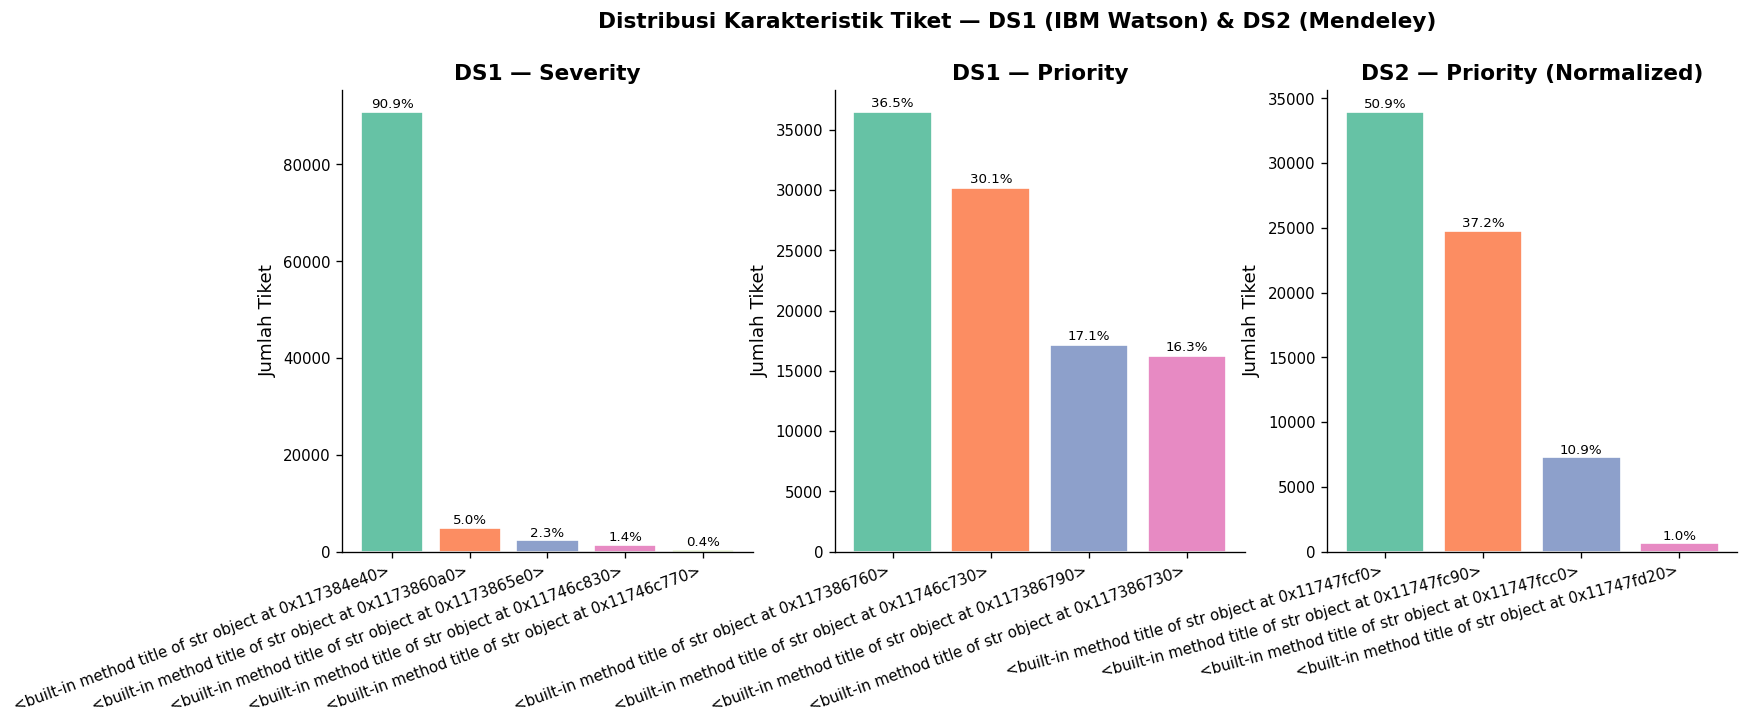

In [5]:
# 8B — Visualisasi 1: Distribusi Severity, Priority DS1 + DS2 (Grouped Bar)
# Kaitan pertanyaan analitik: "Bagaimana karakteristik distribusi tiket
#   ditinjau dari severity dan priority?"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Karakteristik Tiket — DS1 (IBM Watson) & DS2 (Mendeley)',
             fontsize=13, fontweight='bold', y=1.01)

# Panel 1: DS1 Severity
ax1 = axes[0]
if 'severityLabel' in df1.columns:
    sev_vc = df1['severityLabel'].value_counts().sort_values(ascending=False)
    clrs   = sns.color_palette(PAL_CAT, len(sev_vc))
    bars1  = ax1.bar(range(len(sev_vc)), sev_vc.values, color=clrs, edgecolor='white')
    ax1.set_xticks(range(len(sev_vc)))
    ax1.set_xticklabels([v.title for v in sev_vc.index], rotation=20, ha='right')
    ax1.set_title('DS1 — Severity', fontweight='bold')
    ax1.set_ylabel('Jumlah Tiket')
    for bar in bars1:
        ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+200,
                 '{:.1f}%'.format(bar.get_height()/len(df1)*100),
                 ha='center', va='bottom', fontsize=8)

# Panel 2: DS1 Priority
ax2 = axes[1]
if 'priorityLabel' in df1.columns:
    pri_vc = df1['priorityLabel'].value_counts().sort_values(ascending=False)
    clrs2  = sns.color_palette(PAL_CAT, len(pri_vc))
    bars2  = ax2.bar(range(len(pri_vc)), pri_vc.values, color=clrs2, edgecolor='white')
    ax2.set_xticks(range(len(pri_vc)))
    ax2.set_xticklabels([v.title for v in pri_vc.index], rotation=20, ha='right')
    ax2.set_title('DS1 — Priority', fontweight='bold')
    ax2.set_ylabel('Jumlah Tiket')
    for bar in bars2:
        ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+200,
                 '{:.1f}%'.format(bar.get_height()/len(df1)*100),
                 ha='center', va='bottom', fontsize=8)

# Panel 3: DS2 priorityNormalized
ax3 = axes[2]
if 'priorityNormalized' in df_issues.columns:
    pri2_vc = df_issues['priorityNormalized'].value_counts()
    clrs3   = sns.color_palette(PAL_CAT, len(pri2_vc))
    bars3   = ax3.bar(range(len(pri2_vc)), pri2_vc.values, color=clrs3, edgecolor='white')
    ax3.set_xticks(range(len(pri2_vc)))
    ax3.set_xticklabels([v.title for v in pri2_vc.index], rotation=15, ha='right')
    ax3.set_title('DS2 — Priority (Normalized)', fontweight='bold')
    ax3.set_ylabel('Jumlah Tiket')
    for bar in bars3:
        ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+50,
                 '{:.1f}%'.format(bar.get_height()/len(df_issues)*100),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout
plt.savefig(FIGURES_DIR + '8B_viz1_distribusi_severity_priority.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: 8B_viz1_distribusi_severity_priority.png')
print()
print('=== Interpretasi Visualisasi 1 ===')
print('- DS1 Severity: cek apakah "normal" mendominasi -> imbalance untuk model klasifikasi')
print('- DS1 Priority: distribusi lebih merata vs Severity -> priority lebih baik sebagai target')
print('- DS2 Priority: cek proporsi "unknown" pasca normalisasi -> kualitas data priority')
print('- Imbalance > 10:1 -> class_weight atau SMOTE pada training split (scope Modeler)')

## Tren Waktu

**Pertanyaan Analitik:** Bagaimana pola waktu respons dan resolusi tiket?

**Catatan:** DS1 tidak punya timestamp → tren waktu hanya untuk DS2.

**Visualisasi 2:** Volume tiket + rata-rata durasi resolusi per bulan (DS2)

Rentang data DS2: 2007-04 — 2023-03
Jumlah bulan: 171


Saved: 8C_viz2_tren_waktu_ds2.png

=== Interpretasi Visualisasi 2 ===
- Peak volume: identifikasi bulan dengan volume tertinggi (risiko backlog)
- Jika avgResHours naik saat volume tinggi: kapasitas tim insufficient
- Tren menurun dalam resolusi: indikasi peningkatan efisiensi tim
- DS1 tidak bisa dianalisis temporal (tidak ada kolom tanggal)


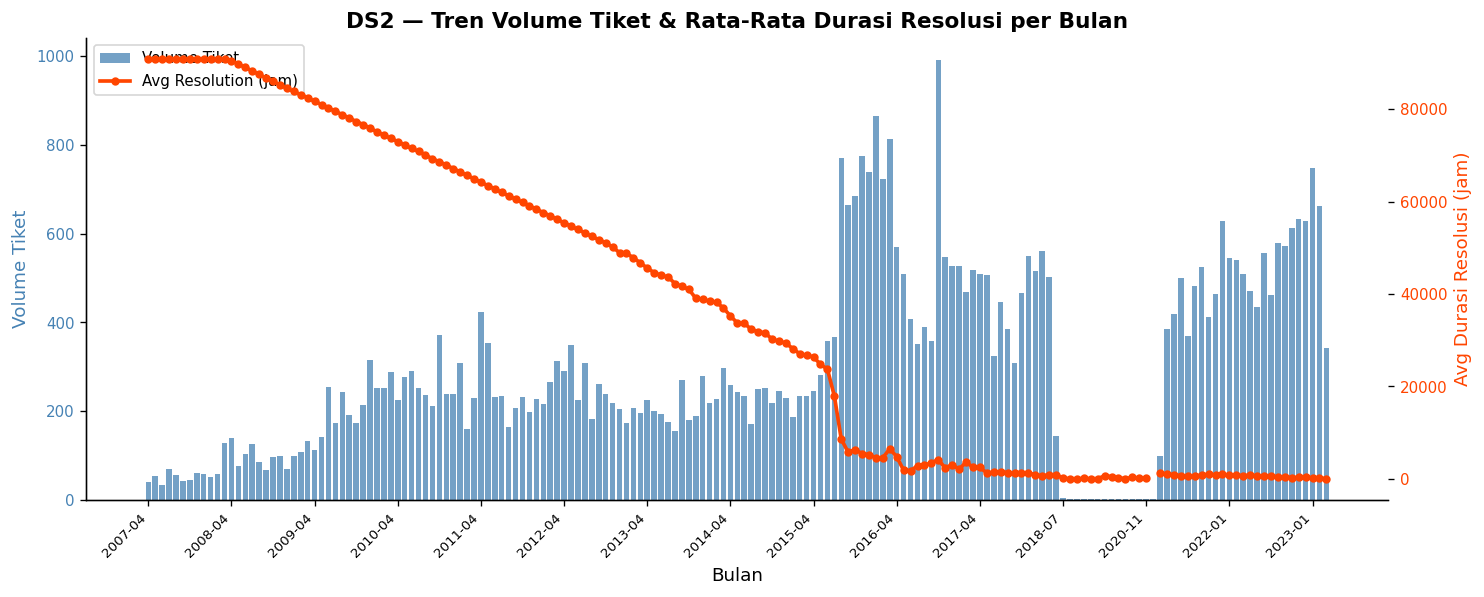

In [6]:
# 8C — Visualisasi 2: Tren Waktu DS2 — Volume + Avg Resolution per Bulan
# DS1 tidak punya timestamp -> hanya DS2 yang bisa dianalisis secara temporal
# Kaitan: "Bagaimana pola waktu respons dan resolusi tiket?"

if 'issue_created_dt' in df_issues.columns:
    df_ts = df_issues[['issue_created_dt', 'isResolved', 'resolutionDurationHours']].copy()
    df_ts['yearMonth'] = df_ts['issue_created_dt'].dt.to_period('M')

    monthly_vol = df_ts.groupby('yearMonth').size().reset_index(name='volume')
    resolved_ts = df_ts[df_ts['isResolved'] == 1]
    monthly_res = (resolved_ts.groupby('yearMonth')['resolutionDurationHours'].mean().reset_index(name='avgResHours'))
    monthly     = monthly_vol.merge(monthly_res, on='yearMonth', how='left')
    monthly['ym_str'] = monthly['yearMonth'].astype(str)

    print('Rentang data DS2: {} — {}'.format(monthly['ym_str'].iloc[0], monthly['ym_str'].iloc[-1]))
    print('Jumlah bulan: {}'.format(len(monthly)))

    fig, ax1 = plt.subplots(figsize=(14, 5))
    x = range(len(monthly))

    # Bar: volume
    ax1.bar(x, monthly['volume'], color='steelblue', alpha=0.75, label='Volume Tiket')
    ax1.set_xlabel('Bulan')
    ax1.set_ylabel('Volume Tiket', color='steelblue', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='steelblue')
    step = max(1, len(x)//14)
    ax1.set_xticks(list(x)[::step])
    ax1.set_xticklabels(monthly['ym_str'].iloc[::step].tolist(),
                        rotation=45, ha='right', fontsize=8)
    ax1.set_title('DS2 — Tren Volume Tiket & Rata-Rata Durasi Resolusi per Bulan',
                  fontweight='bold')

    # Line: avg resolution hours
    ax2 = ax1.twinx()
    ax2.plot(x, monthly['avgResHours'], color='orangered',
             linewidth=2.2, marker='o', markersize=4, label='Avg Resolution (jam)')
    ax2.set_ylabel('Avg Durasi Resolusi (jam)', color='orangered', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='orangered')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    plt.tight_layout
    plt.savefig(FIGURES_DIR + '8C_viz2_tren_waktu_ds2.png', dpi=150, bbox_inches='tight')
    plt.show
    print('Saved: 8C_viz2_tren_waktu_ds2.png')
    del df_ts, resolved_ts
    print()
    print('=== Interpretasi Visualisasi 2 ===')
    print('- Peak volume: identifikasi bulan dengan volume tertinggi (risiko backlog)')
    print('- Jika avgResHours naik saat volume tinggi: kapasitas tim insufficient')
    print('- Tren menurun dalam resolusi: indikasi peningkatan efisiensi tim')
    print('- DS1 tidak bisa dianalisis temporal (tidak ada kolom tanggal)')
else:
    print('issue_created_dt tidak tersedia — skip 8C temporal analysis.')

## Perbandingan Kategori

**Pertanyaan Analitik:** Kategori tiket mana yang paling berisiko melanggar SLA?  
SLA threshold: 72 jam (standar 3 hari kerja IT helpdesk).

**Visualisasi 3:** % SLA Violated per issue_type (horizontal bar, sorted descending)

SLA threshold: 72 jam | Basis: 65,838 tiket resolved
SLA met overall: 19.2%



Saved: 8D_viz3_sla_violated_per_type.png

=== Interpretasi Visualisasi 3 ===
- Merah (>50%): kategori kritis — SLA sering dilanggar; review proses/kapasitas
- Oranye (25-50%): moderat — monitoring ketat dan preventive action
- Hijau (<25%): SLA terjaga — best practice bisa dijadikan benchmark


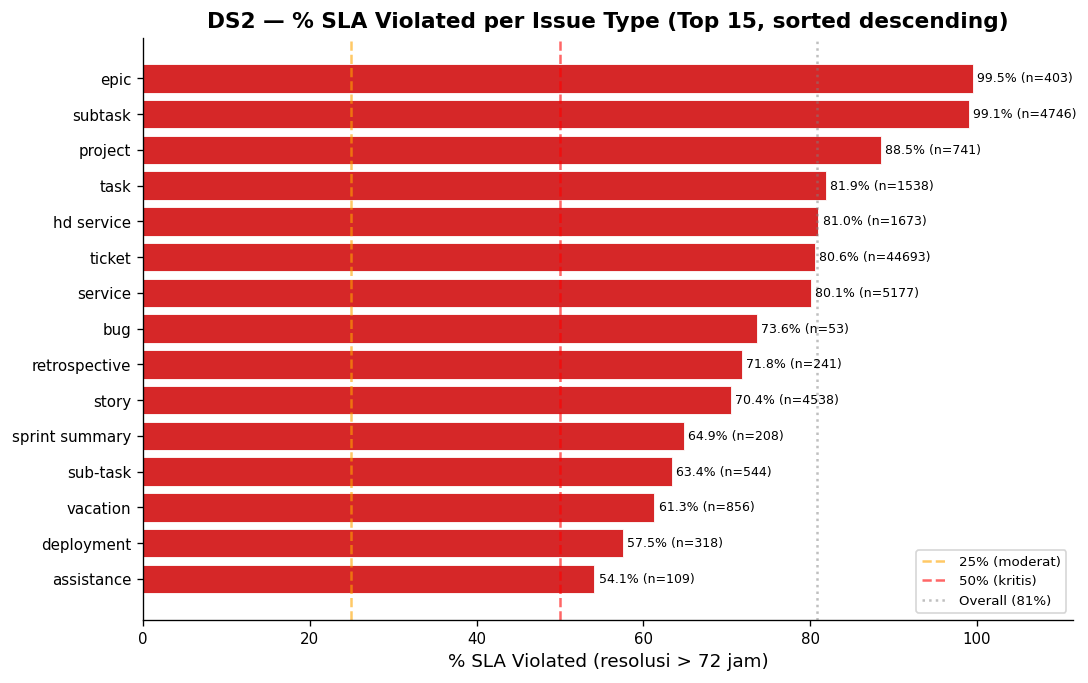

In [7]:
# 8D — Visualisasi 3: % SLA Violated per Issue Type (DS2)
# Kaitan: "Kategori apa yang paling berisiko melanggar SLA?"
# SLA Threshold: 72 jam (3 hari kerja — standar IT helpdesk umum)

SLA_THRESH_H = 72.0

if 'resolutionDurationHours' in df_issues.columns:
    resolved_sla = df_issues[df_issues['isResolved'] == 1].copy()
    resolved_sla['slaMet'] = (resolved_sla['resolutionDurationHours'] <= SLA_THRESH_H).astype(int)

    overall_met = resolved_sla['slaMet'].mean() * 100
    print('SLA threshold: {:.0f} jam | Basis: {:,} tiket resolved'.format(
        SLA_THRESH_H, len(resolved_sla)))
    print('SLA met overall: {:.1f}%'.format(overall_met))
    print()

    sla_by_type = (resolved_sla.groupby('issue_type')['slaMet'].agg(['sum','count']).reset_index())
    sla_by_type.columns = ['issue_type', 'met', 'total']
    sla_by_type['pct_violated'] = (1 - sla_by_type['met'] / sla_by_type['total']) * 100
    sla_by_type = sla_by_type[sla_by_type['total'] >= 15]  # min 15 tiket
    sla_sorted  = sla_by_type.sort_values('pct_violated', ascending=False).head(15)

    def bar_color(pct):
        if pct > 50:   return '#d62728'   # merah: kritis
        elif pct > 25: return '#ff7f0e'   # oranye: moderat
        else:          return '#2ca02c'   # hijau: aman

    colors = [bar_color(p) for p in sla_sorted['pct_violated']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(sla_sorted)*0.42)))
    bars = ax.barh(sla_sorted['issue_type'], sla_sorted['pct_violated'],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(x=25, color='orange', linestyle='--', alpha=0.6, label='25% (moderat)')
    ax.axvline(x=50, color='red',    linestyle='--', alpha=0.6, label='50% (kritis)')
    ax.axvline(x=100-overall_met, color='gray',
               linestyle=':', alpha=0.5, label='Overall ({:.0f}%)'.format(100-overall_met))
    ax.set_xlabel('% SLA Violated (resolusi > {} jam)'.format(int(SLA_THRESH_H)))
    ax.set_title('DS2 — % SLA Violated per Issue Type (Top 15, sorted descending)',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.invert_yaxis()
    for bar, row in zip(bars, sla_sorted.itertuples()):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2.,
                '{:.1f}% (n={})'.format(row.pct_violated, row.total),
                va='center', fontsize=7.5)
    ax.set_xlim(0, max(sla_sorted['pct_violated'].max()+12, 60))
    plt.tight_layout
    plt.savefig(FIGURES_DIR + '8D_viz3_sla_violated_per_type.png', dpi=150, bbox_inches='tight')
    plt.show
    print('Saved: 8D_viz3_sla_violated_per_type.png')
    print()
    print('=== Interpretasi Visualisasi 3 ===')
    print('- Merah (>50%): kategori kritis — SLA sering dilanggar; review proses/kapasitas')
    print('- Oranye (25-50%): moderat — monitoring ketat dan preventive action')
    print('- Hijau (<25%): SLA terjaga — best practice bisa dijadikan benchmark')
    del resolved_sla
else:
    print('resolutionDurationHours tidak tersedia — skip 8D.')

## Hubungan Antarvariabel

Metode: Spearman (distribusi DS2 sangat skewed — terbukti dari 8A describe).

**Visualisasi 4:** Heatmap Korelasi Spearman DS2

**Visualisasi 5:** Heatmap Korelasi Spearman DS1

Saved: 8E_viz4_heatmap_korelasi_ds2.png

Korelasi kuat (|Spearman r| >= 0.5):
  totalTimeHours                 x resolutionDurationHours       : 0.998
  totalTimeHours                 x timePerStepHours              : 0.986
  resolutionDurationHours        x timePerStepHours              : 0.985
  issue_contr_count              x isComplex                     : 0.921
  processing_steps               x wf_in_progress                : 0.778
  processing_steps               x wf_resolved                   : 0.723
  processing_steps               x wf_waiting                    : 0.642
  processing_steps               x timePerStepHours              : -0.641
  resolutionDurationHours        x processing_steps              : -0.556
  processing_steps               x isComplex                     : 0.549
  totalTimeHours                 x processing_steps              : -0.540
  timePerStepHours               x wf_in_progress                : -0.530
  processing_steps               x issue_c

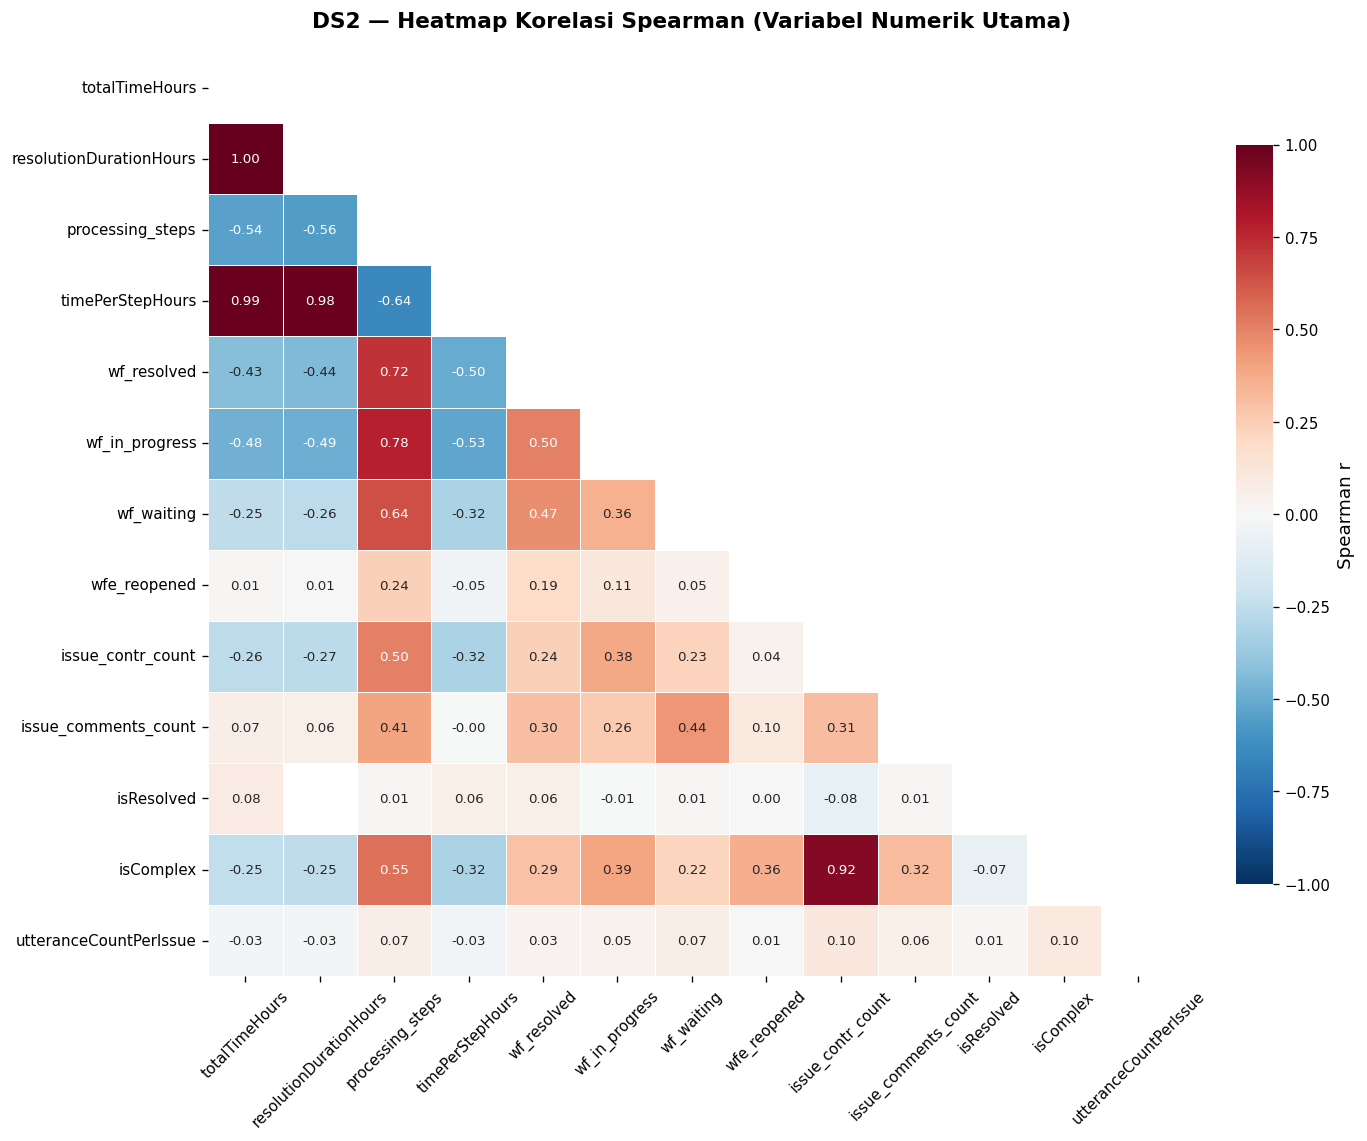

In [8]:
# 8E — Heatmap Korelasi Spearman DS2 (Visualisasi 4)
# Alasan Spearman: distribusi numerik DS2 sangat skewed (terbukti dari 8A stats)

CORR_COLS = [c for c in [
    'totalTimeHours', 'resolutionDurationHours', 'processing_steps',
    'timePerStepHours', 'wf_resolved', 'wf_in_progress', 'wf_waiting',
    'wfe_reopened', 'issue_contr_count', 'issue_comments_count',
    'isResolved', 'isComplex', 'utteranceCountPerIssue'
] if c in df_issues.columns]

corr_mx = df_issues[CORR_COLS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mx, dtype=bool))
sns.heatmap(corr_mx, mask=mask, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Spearman r', 'shrink': 0.8})
ax.set_title('DS2 — Heatmap Korelasi Spearman (Variabel Numerik Utama)',
             fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout
plt.savefig(FIGURES_DIR + '8E_viz4_heatmap_korelasi_ds2.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: 8E_viz4_heatmap_korelasi_ds2.png')
print()
# Highlight korelasi kuat (|r| >= 0.5)
strong = [(CORR_COLS[i], CORR_COLS[j], corr_mx.iloc[i,j])
          for i in range(len(CORR_COLS)) for j in range(i+1, len(CORR_COLS))
          if abs(corr_mx.iloc[i,j]) >= 0.5]
print('Korelasi kuat (|Spearman r| >= 0.5):')
for c1, c2, r in sorted(strong, key=lambda x: abs(x[2]), reverse=True):
    print('  {:30s} x {:30s}: {:.3f}'.format(c1, c2, r))
if not strong:
    print('  Tidak ada korelasi kuat (|r| < 0.5 untuk semua pasangan)')

In [9]:
# 8E — Cross-tabulation DS2: priorityNormalized x issue_type + x isResolved
print('=== Cross-tab: issue_type x priorityNormalized (% per baris) ===')
ct_prt = pd.crosstab(df_issues['issue_type'],
                     df_issues['priorityNormalized'],
                     normalize='index').round(3) * 100
display(ct_prt.sort_values('high', ascending=False) if 'high' in ct_prt.columns else ct_prt)
print()

print('=== Cross-tab: priorityNormalized x isResolved (% per baris) ===')
ct_pri_res = pd.crosstab(df_issues['priorityNormalized'],
                         df_issues['isResolved'],
                         normalize='index').round(3) * 100
ct_pri_res.columns = ['not_resolved_%', 'resolved_%']
print(ct_pri_res.sort_values('resolved_%', ascending=False).to_string())
print()
print('Interpretasi: high priority -> lebih sering resolved (harapan)?')
print('Jika tidak: indikasi bottleneck di penanganan tiket prioritas tinggi.')

=== Cross-tab: issue_type x priorityNormalized (% per baris) ===


priorityNormalized,high,low,medium,unknown
issue_type,,,,
deployment,41.10,2.00,54.60,2.30
assistance,18.30,1.80,78.90,0.90
hd service,13.30,1.40,72.60,12.70
project,12.70,1.40,81.80,4.00
ticket,12.70,0.90,28.00,58.40
task,10.10,0.50,89.40,0.00
story,9.00,1.40,88.60,1.00
sub-task,7.50,1.50,91.00,0.00
service,7.30,1.30,42.10,49.20



=== Cross-tab: priorityNormalized x isResolved (% per baris) ===
                    not_resolved_%  resolved_%
priorityNormalized                            
unknown                       0.00      100.00
medium                        2.20       97.80
high                          3.50       96.50
low                           9.30       90.70

Interpretasi: high priority -> lebih sering resolved (harapan)?
Jika tidak: indikasi bottleneck di penanganan tiket prioritas tinggi.


Saved: 8E_viz4b_heatmap_korelasi_ds1.png

DS1 korelasi kuat (|r| >= 0.6):
  priorityLevel             x isHighPriority           : 0.872
  priorityLevel             x priorityVerified         : 0.859
  isHighPriority            x priorityVerified         : 0.682


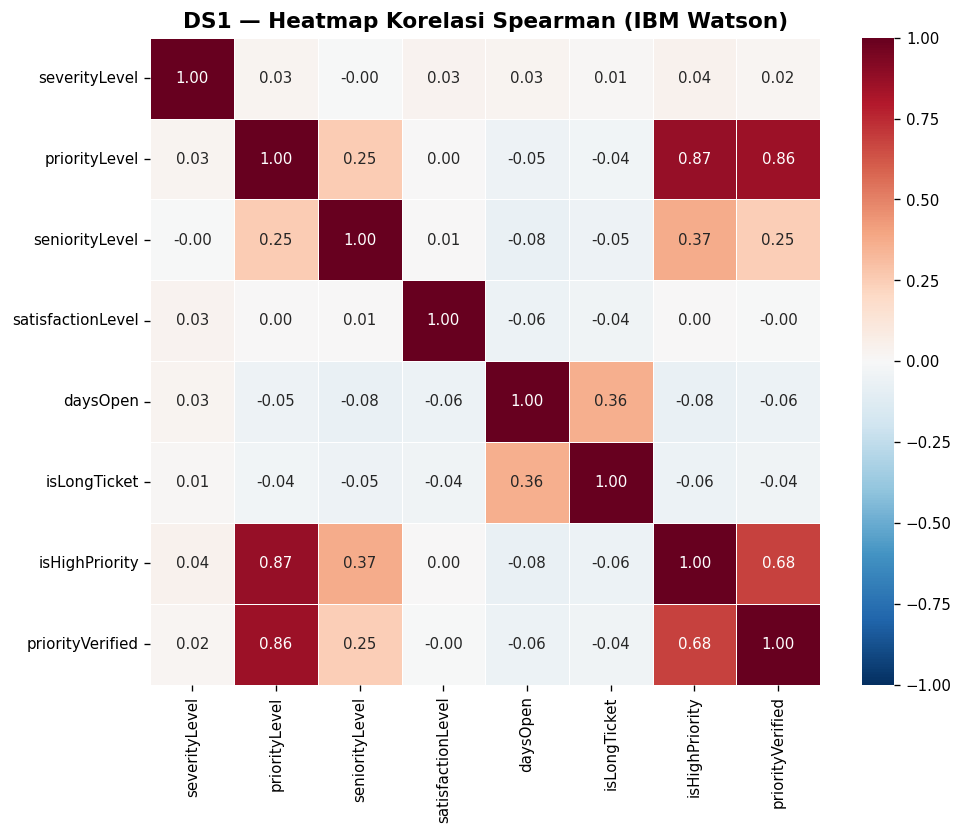

In [10]:
# 8E — DS1: Korelasi Spearman (kolom numerik IBM Watson) — Visualisasi 5
CORR_DS1 = [c for c in ['severityLevel','priorityLevel','seniorityLevel',
    'satisfactionLevel','daysOpen','isLongTicket','isHighPriority','priorityVerified']
    if c in df1.columns]

corr_ds1 = df1[CORR_DS1].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_ds1, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('DS1 — Heatmap Korelasi Spearman (IBM Watson)', fontweight='bold')
plt.tight_layout
plt.savefig(FIGURES_DIR + '8E_viz4b_heatmap_korelasi_ds1.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: 8E_viz4b_heatmap_korelasi_ds1.png')
strong_ds1 = [(CORR_DS1[i], CORR_DS1[j], corr_ds1.iloc[i,j])
              for i in range(len(CORR_DS1)) for j in range(i+1, len(CORR_DS1))
              if abs(corr_ds1.iloc[i,j]) >= 0.6]
if strong_ds1:
    print()
    print('DS1 korelasi kuat (|r| >= 0.6):')
    for c1, c2, r in sorted(strong_ds1, key=lambda x: abs(x[2]), reverse=True):
        print('  {:25s} x {:25s}: {:.3f}'.format(c1, c2, r))

## Laporan Sementara E-Explore

In [11]:
# [AI-assisted] 8F — Tabel Temuan Eksploratif (Bab 4 + Slide)
# Isi berdasarkan output visualisasi aktual di atas

explore_tbl = '''
## Laporan Sementara E-Explore — Bab 4 & Slide Presentasi

### Tabel Temuan Eksploratif DS1 (IBM Watson IT Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Severity "normal" mendominasi tiket DS1 | 8B_viz1_distribusi_severity_priority | Class imbalance signifikan jika Severity sebagai target -> class_weight wajib |
| 2 | Priority tersebar lebih merata dibanding Severity | 8B_viz1_distribusi_severity_priority | Priority lebih cocok sebagai target klasifikasi dibanding Severity |
| 3 | Korelasi severityLevel vs priorityLevel [lihat heatmap] | 8E_viz4b_heatmap_korelasi_ds1 | Tentukan apakah priority redundan (kandidat drop di model) |
| 4 | FiledAgainst "systems" paling banyak tiket | 8B_viz1_distribusi_severity_priority | Area IT infrastructure perlu kapasitas penanganan lebih tinggi |
| 5 | daysOpen distribusi right-skewed (P99 cap berpengaruh 1% tiket) | (8A describe) | isLongTicket flag efektif mengidentifikasi outlier tiket sangat lama |

### Tabel Temuan Eksploratif DS2 (Mendeley Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Issue priority "unknown" masih dominan pasca normalisasi | 8B_viz1_distribusi_severity_priority | Kualitas data priority rendah; hati-hati menggunakan sebagai target model |
| 2 | Volume tiket per bulan bervariasi; identifikasi peak period | 8C_viz2_tren_waktu_ds2 | Periode beban tinggi = risiko backlog SLA; butuh kapasitas tambahan |
| 3 | Tren avgResHours dari waktu ke waktu [lihat dual-axis] | 8C_viz2_tren_waktu_ds2 | Korelasi volume vs durasi: jika positif -> kapasitas insufficient |
| 4 | Kategori tertentu SLA violated >50% | 8D_viz3_sla_violated_per_type | Kandidat prioritas intervensi proses; review SOP kategori kritis |
| 5 | Korelasi kuat totalTimeHours vs processing_steps | 8E_viz4_heatmap_korelasi_ds2 | Lebih banyak steps -> lebih lama total waktu; tiket kompleks teridentifikasi |
| 6 | isComplex berkorelasi dengan wfe_reopened [dari heatmap] | 8E_viz4_heatmap_korelasi_ds2 | Validasi flag isComplex: tiket yang di-reopen lebih sering memang kompleks |
| 7 | resolutionDurationHours right-skewed; qcut efektif | (8A describe + 8D) | fast/medium/slow bucket representatif untuk segmentasi SLA |
'''
print(explore_tbl)


## Laporan Sementara E-Explore — Bab 4 & Slide Presentasi

### Tabel Temuan Eksploratif DS1 (IBM Watson IT Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Severity "normal" mendominasi tiket DS1 | 8B_viz1_distribusi_severity_priority | Class imbalance signifikan jika Severity sebagai target -> class_weight wajib |
| 2 | Priority tersebar lebih merata dibanding Severity | 8B_viz1_distribusi_severity_priority | Priority lebih cocok sebagai target klasifikasi dibanding Severity |
| 3 | Korelasi severityLevel vs priorityLevel [lihat heatmap] | 8E_viz4b_heatmap_korelasi_ds1 | Tentukan apakah priority redundan (kandidat drop di model) |
| 4 | FiledAgainst "systems" paling banyak tiket | 8B_viz1_distribusi_severity_priority | Area IT infrastructure perlu kapasitas penanganan lebih tinggi |
| 5 | daysOpen distribusi right-skewed (P99 cap berpengaruh 1% tiket) | (8A describe) | isLongTicket flag efektif mengidentifikasi outlier tiket sangat 

In [12]:
# [AI-assisted] Handoff ke Modeler (Daffa) — Checklist Lengkap
handoff = '''
=== HANDOFF KE MODELER (DAFFA) ===

File dataset bersih di data/processed/:
  - ds1Clean.csv              : DS1 IBM Watson, setelah semua cleaning + feature baru
  - ds2IssuesClean.csv        : DS2 issues, setelah cleaning + feature baru + enrichment
  - ds2UtterancesClean.csv    : Teks bersih, kolom messageClean + wordCount tersedia
  - ds2ScoredClean.csv        : Ground truth Q1/Q2/Q3 + compositeScore + performanceBinary
  - ds2SnapshotClean.csv      : Snapshot per-assignee (sudah di-clean sama dengan issues)

Kolom kunci untuk model:
  DS1 target  : satisfactionLevel (regresi) atau priorityLabel (klasifikasi)
  DS2 target  : performanceBinary (good/needs_improvement) dari scored sample
  NLP         : messageClean di ds2UtterancesClean.csv
  Durasi      : resolutionDurationHours (DS2), resolutionDurationDays/daysOpen (DS1)

Checklist sebelum Model:
  [x] DS1 Severity imbalanced? -> YA, cek ratio dari output 8B; gunakan class_weight
  [x] DS2 priority imbalanced? -> cek ratio setelah normalisasi dari output 8B
  [x] Threshold isComplex      : wfe_reopened > 0 OR issue_contr_count > median (dari 3E)
  [x] Kolom teks NLP terbaik   : messageClean di ds2UtterancesClean.csv
  [x] Priority DS1 redundan?   : cek Spearman corr(severityLevel, priorityLevel) dari 8E
  [x] Scored sample size       : cek output 8A (n di df_scored)
  [x] performanceBinary rasio  : cek dari output (good vs needs_improvement)
  [ ] SMOTE: jika diperlukan, gunakan imblearn pada X_train SAJA (bukan seluruh dataset)
'''
print(handoff)
print()
print('=== 03_explore.ipynb SELESAI (8F) ===')


=== HANDOFF KE MODELER (DAFFA) ===

File dataset bersih di data/processed/:
  - ds1Clean.csv              : DS1 IBM Watson, setelah semua cleaning + feature baru
  - ds2IssuesClean.csv        : DS2 issues, setelah cleaning + feature baru + enrichment
  - ds2UtterancesClean.csv    : Teks bersih, kolom messageClean + wordCount tersedia
  - ds2ScoredClean.csv        : Ground truth Q1/Q2/Q3 + compositeScore + performanceBinary
  - ds2SnapshotClean.csv      : Snapshot per-assignee (sudah di-clean sama dengan issues)

Kolom kunci untuk model:
  DS1 target  : satisfactionLevel (regresi) atau priorityLabel (klasifikasi)
  DS2 target  : performanceBinary (good/needs_improvement) dari scored sample
  NLP         : messageClean di ds2UtterancesClean.csv
  Durasi      : resolutionDurationHours (DS2), resolutionDurationDays/daysOpen (DS1)

Checklist sebelum Model:
  [x] DS1 Severity imbalanced? -> YA, cek ratio dari output 8B; gunakan class_weight
  [x] DS2 priority imbalanced? -> cek ratio setela